# Improved main baseline

This copy keeps the baseline MSE training objective and fixes consistency issues only: current-control alignment in diagnostics, denormalized NN corrections before integration, physics-only predictions through the same one-step integrator, updated fitted-rate surrogate text, and NED vertical thrust sign.


In [2]:
import torch

def wrap_to_pi(a):
    """Wrap angles to [-pi, pi]."""
    return torch.atan2(torch.sin(a), torch.cos(a))


# ---------------------------------------------------------------------------
# Quaternion helpers (singularity-free attitude representation)
# ---------------------------------------------------------------------------

def euler_to_quat(roll, pitch, yaw):
    """
    Convert ZYX Euler angles to unit quaternion [w, x, y, z].
    roll, pitch, yaw: (B,) tensors  ->  returns (B,4)
    """
    cr, sr = torch.cos(roll * 0.5), torch.sin(roll * 0.5)
    cp, sp = torch.cos(pitch * 0.5), torch.sin(pitch * 0.5)
    cy, sy = torch.cos(yaw * 0.5), torch.sin(yaw * 0.5)
    qw = cr * cp * cy + sr * sp * sy
    qx = sr * cp * cy - cr * sp * sy
    qy = cr * sp * cy + sr * cp * sy
    qz = cr * cp * sy - sr * sp * cy
    return torch.stack([qw, qx, qy, qz], dim=1)  # (B,4)


def quat_mul(q1, q2):
    """
    Hamilton product q1 x q2.
    q1, q2: (B,4) as [w, x, y, z]  ->  returns (B,4)
    """
    w1, x1, y1, z1 = q1[:, 0], q1[:, 1], q1[:, 2], q1[:, 3]
    w2, x2, y2, z2 = q2[:, 0], q2[:, 1], q2[:, 2], q2[:, 3]
    return torch.stack([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
    ], dim=1)  # (B,4)


def quat_normalize(q, eps=1e-8):
    """Normalize quaternion to unit length. q: (B,4) -> (B,4)"""
    return q / (q.norm(dim=1, keepdim=True) + eps)


def omega_to_quat_delta(omega, dt):
    """
    Quaternion increment from body-frame angular velocity (exact axis-angle).
    omega: (B,3) [wx, wy, wz]  dt: (B,1) or scalar  ->  returns (B,4)
    """
    half_angle_vec = 0.5 * omega * dt              # (B,3)
    angle = half_angle_vec.norm(dim=1, keepdim=True)  # (B,1)
    # sinc(angle) = sin(angle)/angle, numerically safe for angle -> 0
    sinc = torch.where(angle > 1e-8,
                       torch.sin(angle) / angle,
                       torch.ones_like(angle))
    dqw   = torch.cos(angle)          # (B,1)
    dqxyz = sinc * half_angle_vec     # (B,3)
    return torch.cat([dqw, dqxyz], dim=1)  # (B,4)


def quat_to_euler(q):
    """
    Convert unit quaternion [w, x, y, z] to ZYX Euler angles [roll, pitch, yaw].
    q: (B,4)  ->  returns (B,3)
    """
    w, x, y, z = q[:, 0], q[:, 1], q[:, 2], q[:, 3]
    # roll (x-axis rotation)
    sinr_cosp = 2.0 * (w * x + y * z)
    cosr_cosp = 1.0 - 2.0 * (x * x + y * y)
    roll = torch.atan2(sinr_cosp, cosr_cosp)
    # pitch (y-axis) -- clamped to avoid NaN from asin
    sinp = torch.clamp(2.0 * (w * y - z * x), -1.0, 1.0)
    pitch = torch.asin(sinp)
    # yaw (z-axis rotation)
    siny_cosp = 2.0 * (w * z + x * y)
    cosy_cosp = 1.0 - 2.0 * (y * y + z * z)
    yaw = torch.atan2(siny_cosp, cosy_cosp)
    return torch.stack([roll, pitch, yaw], dim=1)  # (B,3)


**Step 1: System Dynamics**

In [3]:
import torch

# Learned affine inner-loop surrogate for body-rate commands.
# These values are re-estimated from the training set in the dataset cell below.
RATE_W_COEF = torch.tensor([-20.0, -20.0, -12.5], dtype=torch.float32)  # multiplies current body rate
RATE_U_COEF = torch.tensor([20.0, 20.0, 12.5], dtype=torch.float32)     # multiplies logged body-rate command
RATE_BIAS   = torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32)

def system_dynamics(state_vector, control_input, mass, inertia, g):
    """
    Drone dynamics with real logged controls:
      control_input = [thrust, cmd_roll_rate, cmd_pitch_rate, cmd_yaw_rate]

    Translational channel:
      Uses thrust directly in the world-frame acceleration equations.

    Rotational channel:
      Uses a fitted affine surrogate for the hidden PX4 inner-loop:
          w_dot = a * w + b * u_rate + c
      fit from training data, per axis.
    """
    if not isinstance(inertia, torch.Tensor):
        inertia = torch.tensor(inertia, dtype=state_vector.dtype, device=state_vector.device)
    else:
        inertia = inertia.to(device=state_vector.device, dtype=state_vector.dtype)

    rate_w = RATE_W_COEF.to(device=state_vector.device, dtype=state_vector.dtype)
    rate_u = RATE_U_COEF.to(device=state_vector.device, dtype=state_vector.dtype)
    rate_b = RATE_BIAS.to(device=state_vector.device, dtype=state_vector.dtype)

    x, y, z = state_vector[:,0], state_vector[:,1], state_vector[:,2]
    roll, pitch, yaw = state_vector[:,3], state_vector[:,4], state_vector[:,5]
    vx, vy, vz = state_vector[:,6], state_vector[:,7], state_vector[:,8]
    w_roll, w_pitch, w_yaw = state_vector[:,9], state_vector[:,10], state_vector[:,11]

    thrust = control_input[:,0]
    cmd_rates = control_input[:,1:4]

    # world-frame kinematics
    x_dot = vx
    y_dot = vy
    z_dot = vz

    roll_dot  = w_roll + torch.sin(roll) * torch.tan(pitch) * w_pitch + torch.cos(roll) * torch.tan(pitch) * w_yaw
    pitch_dot = torch.cos(roll) * w_pitch - torch.sin(roll) * w_yaw
    yaw_dot   = (torch.sin(roll) / torch.cos(pitch)) * w_pitch + (torch.cos(roll) / torch.cos(pitch)) * w_yaw

    # NED convention: z positive downwards
    vx_dot = (thrust / mass) * (torch.cos(roll) * torch.sin(pitch) * torch.cos(yaw) + torch.sin(roll) * torch.sin(yaw))
    vy_dot = (thrust / mass) * (torch.cos(roll) * torch.sin(pitch) * torch.sin(yaw) - torch.sin(roll) * torch.cos(yaw))
    vz_dot = g + (thrust / mass) * (torch.cos(roll) * torch.cos(pitch))

    w_body = state_vector[:, 9:12]
    w_dot_body = rate_w.view(1, 3) * w_body + rate_u.view(1, 3) * cmd_rates + rate_b.view(1, 3)

    state_vector_dot = torch.stack([
        x_dot, y_dot, z_dot,
        roll_dot, pitch_dot, yaw_dot,
        vx_dot, vy_dot, vz_dot,
        w_dot_body[:, 0], w_dot_body[:, 1], w_dot_body[:, 2]
    ], dim=1)

    return state_vector_dot


**Step 2: NN model**

In [3]:
import torch
import torch.nn as nn

class ResidualBModel(nn.Module):
    """
    Physics-informed residual model.

    Input features (16-dim, normalized internally):
        [sin/cos(roll,pitch,yaw)(6), v_norm(3), w_norm(3), u_norm(4)]
    Output (6-dim, derivative corrections):
        [vdot_corr(3), wdot_corr(3)]  units: m/s^2 and rad/s^2

    The NN corrects the physics derivative directly (dt-agnostic):
        vdot_total = vdot_phys + vdot_corr
        wdot_total = wdot_phys + wdot_corr
    Velocities (v, w) and controls (u) are normalized internally using
    stored statistics before being fed to the network.

    dropout_rate: dropout probability applied after each hidden activation
                  (set 0.0 to disable; typical values 0.05 - 0.2)
    """
    def __init__(self, hidden_layers_size, activation_fn,
                 output_activation=nn.Identity, dropout_rate=0.0,
                 vel_mean=None,     vel_std=None,
                 ang_vel_mean=None, ang_vel_std=None,
                 ctrl_mean=None,    ctrl_std=None):
        super().__init__()
        self.n_out = 6
        n_control = 4
        n_input = 6 + 3 + 3 + n_control  # 16

        layers = [nn.Linear(n_input, hidden_layers_size[0]), activation_fn()]
        if dropout_rate > 0.0:
            layers.append(nn.Dropout(p=dropout_rate))
        for i in range(len(hidden_layers_size) - 1):
            layers += [nn.Linear(hidden_layers_size[i], hidden_layers_size[i + 1]), activation_fn()]
            if dropout_rate > 0.0:
                layers.append(nn.Dropout(p=dropout_rate))
        layers += [nn.Linear(hidden_layers_size[-1], self.n_out), output_activation()]
        self.corr_net = nn.Sequential(*layers)

        for m in self.corr_net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        # ---------- input normalisation buffers (not trainable) ----------
        def _mbuf(v, size):
            return (torch.zeros(size, dtype=torch.float32) if v is None
                    else torch.as_tensor(v, dtype=torch.float32).view(size))
        def _sbuf(v, size):
            return (torch.ones(size, dtype=torch.float32) if v is None
                    else torch.as_tensor(v, dtype=torch.float32).view(size))

        self.register_buffer('vel_mean',     _mbuf(vel_mean,     3))
        self.register_buffer('vel_std',      _sbuf(vel_std,      3))
        self.register_buffer('ang_vel_mean', _mbuf(ang_vel_mean, 3))
        self.register_buffer('ang_vel_std',  _sbuf(ang_vel_std,  3))
        self.register_buffer('ctrl_mean',    _mbuf(ctrl_mean,    4))
        self.register_buffer('ctrl_std',     _sbuf(ctrl_std,     4))

    def build_features(self, state_vector, control_input):
        """
        Build normalised 16-dim feature vector.
        state_vector : (B,12) [x,y,z, roll,pitch,yaw, vx,vy,vz, w_roll,w_pitch,w_yaw]
        control_input: (B,4)  [thrust, tau_roll, tau_pitch, tau_yaw]
        """
        roll  = state_vector[:, 3]
        pitch = state_vector[:, 4]
        yaw   = state_vector[:, 5]

        trig = torch.stack([
            torch.sin(roll), torch.cos(roll),
            torch.sin(pitch), torch.cos(pitch),
            torch.sin(yaw),   torch.cos(yaw),
        ], dim=1)  # (B,6)

        v = (state_vector[:, 6:9]  - self.vel_mean)     / self.vel_std      # (B,3)
        w = (state_vector[:, 9:12] - self.ang_vel_mean) / self.ang_vel_std  # (B,3)
        u = (control_input          - self.ctrl_mean)    / self.ctrl_std     # (B,4)

        return torch.cat([trig, v, w, u], dim=1)  # (B,16)

    def forward(self, state_vector, control_input):
        z = self.build_features(state_vector, control_input)  # (B,16)
        return self.corr_net(z)  # (B,6): [vdot_corr(3), wdot_corr(3)]


**Step 3: Data preprocessing**

In [4]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def dataset_masking(dataset=None):

    # Add dt column at position 1 (limiting the number to 6 decimal points)
    dataset.insert(1, 'dt', dataset['time'].diff().fillna(0).round(6))  # Calculate time intervals (dt) between consecutive samples and place it in a new column 'dt' in position 1

    # Add Euler angles columns (roll, pitch, yaw) at positions 17, 18, 19
    dataset.insert(17, 'roll', 0.0)
    dataset.insert(18, 'pitch', 0.0)
    dataset.insert(19, 'yaw', 0.0)

    # Add the following non-used columns to match the old dataset format
    dataset.insert(24, 'pwm_1', 0.0)
    dataset.insert(25, 'pwm_2', 0.0)
    dataset.insert(26, 'pwm_3', 0.0)
    dataset.insert(27, 'pwm_4', 0.0)
    dataset.insert(28, 'total_thrust', 0.0)

    # Keep three legacy placeholder columns after the logged body-rate commands.
    # These columns are no longer used as controls. They only preserve the old
    # dataset layout so the rest of the notebook can be patched incrementally.
    dataset.insert(33, 'unused_legacy_1', 0.0)
    dataset.insert(34, 'unused_legacy_2', 0.0)
    dataset.insert(35, 'unused_legacy_3', 0.0)

    # Drop the unused columns (from 40 to the end, keeping x_ref..yaw_ref)
    dataset = dataset.drop(columns=dataset.columns[40:])

    return dataset

def from_quaternion_to_euler(dataset=None):
    """
    Convert quaternion orientation to Euler angles (roll, pitch, yaw) in the dataset.
    Quaternion format in dataset: [q_w, q_x, q_y, q_z]
    Euler angles format: [roll, pitch, yaw]
    """
    q_w = dataset[:, 20:21]
    q_x = dataset[:, 21:22]
    q_y = dataset[:, 22:23]
    q_z = dataset[:, 23:24]

    # Compute roll (x-axis rotation)
    sinr_cosp = 2 * (q_w * q_x + q_y * q_z)
    cosr_cosp = 1 - 2 * (q_x**2 + q_y**2)
    roll = np.arctan2(sinr_cosp, cosr_cosp)

    # Compute pitch (y-axis rotation)
    sinp = 2 * (q_w * q_y - q_z * q_x)
    pitch = np.where(np.abs(sinp) >= 1, np.sign(sinp) * (np.pi / 2), np.arcsin(sinp))

    # Compute yaw (z-axis rotation)
    siny_cosp = 2 * (q_w * q_z + q_x * q_y)
    cosy_cosp = 1 - 2 * (q_y**2 + q_z**2)
    yaw = np.arctan2(siny_cosp, cosy_cosp)

    # Replace quaternion columns with Euler angles in the dataset (rounding to 6 decimal points)
    dataset[:, 17:18] = np.round(roll, 6)
    dataset[:, 18:19] = np.round(pitch, 6)
    dataset[:, 19:20] = np.round(yaw, 6)

    return dataset

def px4_pwm_to_thrust(dataset = None, mass=2.0, g=9.81):
    """
    1) I need to clamp the values of cmd_thrust between -1 and 0, because out of this interval the drone will read only -1 and 0, so it doesn't make sense to have values outside this range
    2) The cmd_thrust in the dataset is a PWM (or another signal), so i need to apply a conversion factor to get the actual thrust force. This factor is determined empirically to match the hover condition
    """
    cmd_thrust = dataset[:, 29:30] 
    cmd_thrust = np.clip(cmd_thrust, -1.0, 0.0)  # Clamp between -1 and 0

    thrust = cmd_thrust * mass * g / 0.72 #-0.72 # conversion factor to get thrust in Newtons
    dataset[:, 29:30] = np.round(thrust, 6)

    return dataset



def px4_angular_rate_to_torque(
    dataset=None,
    inertia=np.array([0.0216, 0.0216, 0.04]),
    use_fd_alpha: bool = True,  # <-- NEW
):
    """
    Compute torques by inverting Euler rotational dynamics.

    If use_fd_alpha=True, compute angular acceleration from finite differences:
        alpha_k ≈ (omega_{k+1} - omega_k) / dt_k
    This is often better time-aligned than logged alpha channels (which may be filtered/lagged).
    """

    I_x, I_y, I_z = inertia[0], inertia[1], inertia[2]

    # body rates
    w_roll  = dataset[:, 11:12]
    w_pitch = dataset[:, 12:13]
    w_yaw   = dataset[:, 13:14]

    if use_fd_alpha:
        dt = dataset[:, 1:2]
        # finite-difference alpha (same length, last row repeats previous alpha)
        alpha_roll  = np.zeros_like(w_roll)
        alpha_pitch = np.zeros_like(w_pitch)
        alpha_yaw   = np.zeros_like(w_yaw)

        # avoid divide-by-zero at segment boundaries (dt==0 marks new trajectory)
        valid = (dt[1:] > 0)

        dw_roll  = (w_roll[1:]  - w_roll[:-1])
        dw_pitch = (w_pitch[1:] - w_pitch[:-1])
        dw_yaw   = (w_yaw[1:]   - w_yaw[:-1])

        alpha_roll[1:][valid[:, 0]]  = (dw_roll[valid[:, 0]]  / dt[1:][valid[:, 0]])
        alpha_pitch[1:][valid[:, 0]] = (dw_pitch[valid[:, 0]] / dt[1:][valid[:, 0]])
        alpha_yaw[1:][valid[:, 0]]   = (dw_yaw[valid[:, 0]]   / dt[1:][valid[:, 0]])

        # simple fill for invalid points (start of segment): keep 0
        # (alternatively copy next valid value)
    else:
        # use logged alpha columns
        alpha_roll  = dataset[:, 14:15]
        alpha_pitch = dataset[:, 15:16]
        alpha_yaw   = dataset[:, 16:17]

    # invert dynamics to get torque
    tau_x = I_x * alpha_roll  - (I_y - I_z) * w_pitch * w_yaw
    tau_y = I_y * alpha_pitch - (I_z - I_x) * w_roll  * w_yaw
    tau_z = I_z * alpha_yaw   - (I_x - I_y) * w_roll  * w_pitch

    dataset[:, 33:34] = np.round(tau_x, 6)
    dataset[:, 34:35] = np.round(tau_y, 6)
    dataset[:, 35:36] = np.round(tau_z, 6)

    return dataset

def get_mean_and_std(dataset=None):
    """
    Get mean and standard deviation of the whole dataset for normalization.
    Controls use the logged PX4 inputs [cmd_thrust, cmd_roll_rate, cmd_pitch_rate, cmd_yaw_rate].
    """
    time = dataset[:, 0:1]
    dt = dataset[:, 1:2]
    linear_pos = dataset[:, 2:5]
    linear_vel = dataset[:, 5:8]
    linear_acc = dataset[:, 8:11]
    angular_vel = dataset[:, 11:14]
    angular_acc = dataset[:, 14:17]
    angular_pos = dataset[:, 17:20]
    rest_of_the_data = dataset[:, 20:29]
    controls = dataset[:, 29:33]

    lin_pos_mean = linear_pos.mean(axis=0)
    lin_pos_std = linear_pos.std(axis=0) + 1e-8

    lin_vel_mean = linear_vel.mean(axis=0)
    lin_vel_std = linear_vel.std(axis=0) + 1e-8

    lin_acc_mean = linear_acc.mean(axis=0)
    lin_acc_std = linear_acc.std(axis=0) + 1e-8

    ang_vel_mean = angular_vel.mean(axis=0)
    ang_vel_std = angular_vel.std(axis=0) + 1e-8

    ang_acc_mean = angular_acc.mean(axis=0)
    ang_acc_std = angular_acc.std(axis=0) + 1e-8

    controls_mean = controls.mean(axis=0)
    controls_std = controls.std(axis=0) + 1e-8

    mean = np.hstack((lin_pos_mean, lin_vel_mean, ang_vel_mean, lin_acc_mean, ang_acc_mean, controls_mean))
    std = np.hstack((lin_pos_std, lin_vel_std, ang_vel_std, lin_acc_std, ang_acc_std, controls_std))

    return mean, std


def split_data(dataset=None, time_period = 1, dt=0.2, t0 = 30, t1 = 150, t2 = 220):
    """
    Split dataset into training, validation, and testing sets based on time intervals.
    """
    m, _ = dataset.shape

    # Define the delta_t in terms of number of samples
    delta_t = int(time_period / dt)  # number of samples corresponding to the time_period (3/0.2 = 15 samples)

    # Find the first index that corresponding to t0, t1, t2
    start_t0 = np.searchsorted(dataset[:, 0], t0) # index where time >= t0 ( it takes the first index that satisfies the condition)
    start_t1 = np.searchsorted(dataset[:, 0], t1) 
    start_t2 = np.searchsorted(dataset[:, 0], t2)

    end_t0 = start_t0 + delta_t
    end_t1 = start_t1 + delta_t
    end_t2 = start_t2 + delta_t 
    
    data_test_0 = dataset[ start_t0:end_t0, : ]  
    data_test_1 = dataset[ start_t1:end_t1, : ]  
    data_test_2 = dataset[ start_t2:end_t2, : ]

    # Make an array for the tests
    data_test = [data_test_0, data_test_1, data_test_2]

    # Separate testing data from the rest
    data_train_val_0 = dataset[0:start_t0, :]
    data_train_val_1 = dataset[end_t0:start_t1, :]
    data_train_val_2 = dataset[end_t1:start_t2, :]
    data_train_val_3 = dataset[end_t2:m, :]

    # Ensure that the testing/validation samples are evenly distributed in each set, to ease the pair creation (current, next)
    if (data_train_val_0.shape[0] % 2) != 0:
        data_train_val_0 = data_train_val_0[:-1, :] # remove the last sample if odd
    if (data_train_val_1.shape[0] % 2) != 0:
        data_train_val_1 = data_train_val_1[:-1, :]
    if (data_train_val_2.shape[0] % 2) != 0:
        data_train_val_2 = data_train_val_2[:-1, :]
    if (data_train_val_3.shape[0] % 2) != 0:
        data_train_val_3 = data_train_val_3[:-1, :]

    data_train_val = np.vstack((data_train_val_0, data_train_val_1, data_train_val_2, data_train_val_3))

    return data_test, data_train_val
    
def configure_data(dataset):
    m, n = dataset.shape
    dt_test = dataset[:, 1:2]
    linear_pos = dataset[:,2:5]
    linear_vel = dataset[:,5:8]
    linear_acc = dataset[:, 8:11]
    angular_vel = dataset[:,11:14]
    angular_acc = dataset[:, 14:17]
    angular_pos = dataset[:,17:20]
    states = np.hstack((linear_pos, angular_pos, linear_vel, angular_vel, linear_acc, angular_acc))
    controls = dataset[:, 29:33]  # cmd_thrust, cmd_roll_rate, cmd_pitch_rate, cmd_yaw_rate

    return states, controls, dt_test


def create_and_shuffle_pairs(data=None):
    """
    Create (current, next) pairs from time-ordered data and shuffle them.

    Cross-trajectory boundary pairs are excluded: when multiple flight
    segments are stacked vertically, the first row of each new segment has
    dt == 0 (set by dataset_masking).  Using that row as the "next" state
    of the previous segment would interlink two different trajectories, so
    such pairs are filtered out before shuffling.
    """
    # Valid pairs: next row must NOT be the start of a new trajectory (dt != 0)
    valid_mask    = data[1:, 1] != 0.0        # column 1 is dt
    valid_indices = np.where(valid_mask)[0]   # indices i where (i, i+1) is valid

    current_samples = data[valid_indices]
    next_samples    = data[valid_indices + 1]

    # Shuffle for i.i.d. training
    rng     = np.random.default_rng(42)
    perm    = rng.permutation(len(valid_indices))

    return current_samples[perm], next_samples[perm]

def configure_training_and_validation_data(
    data_current=None,
    data_next=None,
    use_next_controls: bool = True,
):
    """
    Prepare paired data for training.

    Controls now use the *logged real control inputs*:
        [cmd_thrust, cmd_roll_rate, cmd_pitch_rate, cmd_yaw_rate]

    This removes the leakage path where body torques were reconstructed from the
    same measured angular velocities that the model is asked to predict.

    If use_next_controls=True, use controls from the next row (k+1) as the
    control applied over the interval [k, k+1].
    """

    # ---------- current state ----------
    linear_pos_curr     = data_current[:, 2:5]
    angular_pos_curr    = data_current[:, 17:20]
    linear_vel_curr     = data_current[:, 5:8]
    angular_vel_curr    = data_current[:, 11:14]
    linear_acc_curr     = data_current[:, 8:11]
    angular_acc_curr    = data_current[:, 14:17]

    states_curr = np.hstack((
        linear_pos_curr,
        angular_pos_curr,
        linear_vel_curr,
        angular_vel_curr,
        linear_acc_curr,
        angular_acc_curr
    ))

    # ---------- next state ----------
    dt = data_next[:, 1]
    linear_pos_next   = data_next[:, 2:5]
    angular_pos_next  = data_next[:, 17:20]
    linear_vel_next   = data_next[:, 5:8]
    angular_vel_next  = data_next[:, 11:14]
    linear_acc_next   = data_next[:, 8:11]
    angular_acc_next  = data_next[:, 14:17]

    states_next = np.hstack((
        linear_pos_next,
        angular_pos_next,
        linear_vel_next,
        angular_vel_next,
        linear_acc_next,
        angular_acc_next
    ))

    # ---------- real logged controls ----------
    uk = data_current[:, 29:33]   # thrust + body-rate commands
    U_next = data_next[:, 29:33]  # thrust + body-rate commands
    U_applied = U_next if use_next_controls else uk

    # ---------- dtype + tensors ----------
    xk = torch.tensor(np.array(states_curr, dtype=np.float32))
    X_next = torch.tensor(np.array(states_next, dtype=np.float32))
    U_applied = torch.tensor(np.array(U_applied, dtype=np.float32))
    dt = torch.tensor(np.array(dt, dtype=np.float32))

    return xk, X_next, U_applied, dt


def save_pairs_to_csv(X_current=None, X_next=None, uk=None, U_next=None, dt=None, filename=None):
    """
    Save paired data to CSV with clear structure for inspection.
    """
    import pandas as pd
    
    # Convert tensors to numpy if needed
    if isinstance(X_current, torch. Tensor):
        X_current = X_current.cpu().numpy()
        xk = X_next. cpu().numpy()
        uk = uk.cpu().numpy()
        U_next = U_next.cpu().numpy()
        dt = dt.cpu().numpy()
    
    # Create a dataframe with descriptive column names
    df = pd.DataFrame({
        # Pair index
        'pair_idx':  np.arange(len(X_current)),
        
        # Time step
        'dt': dt,
        
        # Current state
        'curr_x': X_current[:, 0],
        'curr_y': X_current[:, 1],
        'curr_z': X_current[:, 2],
        'curr_roll': X_current[:, 3],
        'curr_pitch': X_current[:, 4],
        'curr_yaw': X_current[:, 5],
        'curr_vx': X_current[:, 6],
        'curr_vy': X_current[:, 7],
        'curr_vz': X_current[:, 8],
        'curr_wx': X_current[:, 9],
        'curr_wy': X_current[:, 10],
        'curr_wz': X_current[:, 11],
        'curr_ax': X_current[:, 12],
        'curr_ay': X_current[:, 13],
        'curr_az': X_current[:, 14],
        'curr_alpha_x': X_current[:, 15],
        'curr_alpha_y': X_current[:, 16],
        'curr_alpha_z': X_current[:, 17],

        # Current controls
        'thrust': uk[:, 0],
        'torque_roll': uk[:, 1],
        'torque_pitch': uk[:, 2],
        'torque_yaw': uk[: , 3],
        
        # Next state
        'next_x': X_next[:, 0],
        'next_y': X_next[:, 1],
        'next_z': X_next[:, 2],
        'next_roll': X_next[:, 3],
        'next_pitch': X_next[:, 4],
        'next_yaw': X_next[:, 5],
        'next_vx': X_next[:, 6],
        'next_vy': X_next[:, 7],
        'next_vz': X_next[:, 8],
        'next_wx': X_next[:, 9],
        'next_wy': X_next[:, 10],
        'next_wz': X_next[:, 11],
        'next_ax': X_next[:, 12],
        'next_ay': X_next[:, 13],
        'next_az': X_next[:, 14],
        'next_alpha_x': X_next[:, 15],
        'next_alpha_y': X_next[:, 16],
        'next_alpha_z': X_next[:, 17],

        # Next controls
        'thrust': U_next[:, 0],
        'torque_roll': U_next[:, 1],
        'torque_pitch': U_next[:, 2],
        'torque_yaw': U_next[: , 3],
    })
    
    
    # Save to CSV
    df.to_csv(filename, index=False, float_format='%.6f')
    print(f"✅ Saved {len(df)} pairs to '{filename}'")
    
    return df



def normalize_NN_inputs(X_current=None, uk=None, mean=None, std=None):
    """
    Normalize NN inputs using provided mean and std.
    """
    # Unpack mean and std
    lin_pos_mean, lin_vel_mean, ang_vel_mean, lin_acc_mean, ang_acc_mean, controls_mean = mean[:3], mean[3:6], mean[6:9], mean[9:12], mean[12:15], mean[15:19]
    lin_pos_std, lin_vel_std, ang_vel_std, lin_acc_std, ang_acc_std, controls_std = std[:3], std[3:6], std[6:9], std[9:12], std[12:15], std[15:19]

    # Normalize current states
    linear_pos_curr_norm = (X_current[:3] - lin_pos_mean) / lin_pos_std
    linear_vel_curr_norm = (X_current[6:9] - lin_vel_mean) / lin_vel_std
    angular_vel_curr_norm = (X_current[9:12] - ang_vel_mean) / ang_vel_std
    # linear_acc_curr_norm = (X_current[12:15] - lin_acc_mean) / lin_acc_std
    # angular_acc_curr_norm = (X_current[15:18] - ang_acc_mean) / ang_acc_std
    controls_curr_norm = (uk - controls_mean) / controls_std

    # Reconstruct normalized current state tensor
    X_current_norm = np.concatenate((linear_pos_curr_norm, X_current[3:6], linear_vel_curr_norm, angular_vel_curr_norm)) #, linear_acc_curr_norm, angular_acc_curr_norm))
    U_curr_norm = controls_curr_norm

    return X_current_norm, U_curr_norm



def denormalize_NN_outputs(X_pred=None, mean=None, std=None):
    """
    Denormalize NN outputs using provided mean and std.
    """
    # Move mean and std from cpu to the same device as X_pred
    mean = torch.tensor(mean, dtype=torch.float32, device=X_pred.device)
    std = torch.tensor(std, dtype=torch.float32, device=X_pred.device)

    # Unpack mean and std
    lin_pos_mean, lin_vel_mean, ang_vel_mean, lin_acc_mean, ang_acc_mean, controls_mean = mean[:3], mean[3:6], mean[6:9], mean[9:12], mean[12:15], mean[15:19]
    lin_pos_std, lin_vel_std, ang_vel_std, lin_acc_std, ang_acc_std, controls_std = std[:3], std[3:6], std[6:9], std[9:12], std[12:15], std[15:19]

    # Denormalize predicted states
    linear_acc_pred_denorm = X_pred[:,:3] * lin_acc_std + lin_acc_mean
    angular_acc_pred_denorm = X_pred[:,3:6] * ang_acc_std + ang_acc_mean
    linear_vel_pred_denorm = X_pred[:,6:9] * lin_vel_std + lin_vel_mean
    angular_vel_pred_denorm = X_pred[:,9:12] * ang_vel_std + ang_vel_mean
    

    # Reconstruct denormalized next state tensor
    # X_pred_denorm = np.concatenate((linear_acc_denorm, angular_acc_denorm, linear_vel_denorm, angular_vel_denorm))
    X_pred_norm = torch.cat((linear_acc_pred_denorm, angular_acc_pred_denorm, linear_vel_pred_denorm, angular_vel_pred_denorm), dim=1) # dim=1 to concatenate along the feature dimension

    return X_pred_norm

def diff_sysdyn_dataset(state_vector, control_input, mass, inertia, g, dt, X_next):
    """
    Compute the error between the approximated system dynamics and the dataset derivatives.
    """
    # Compute the approximated derivatives using the system dynamics function
    state_vector_dot_approx = system_dynamics(state_vector, control_input, mass, inertia, g)

    # Euler integration to get the next state from the current state and the approximated derivatives
    state_vector_next_approx = state_vector + state_vector_dot_approx * dt

    # Compute the error between the approximated and actual next states
    error = X_next - state_vector_next_approx

    return error, state_vector_next_approx


In [5]:
class DynamicsNormalizer(nn.Module):
    def __init__(self, pos_scale, angle_scale, vel_scale, omega_scale, u_scale):
        super().__init__()

        self.register_buffer("pos_scale", torch.tensor(pos_scale))
        self.register_buffer("angle_scale", torch.tensor(angle_scale))
        self.register_buffer("vel_scale", torch.tensor(vel_scale))
        self.register_buffer("omega_scale", torch.tensor(omega_scale))
        self.register_buffer("u_scale", torch.tensor(u_scale))

    # ---------------- STATE ----------------
    def normalize_state(self, X):
        X = X.clone()
        X[:, 0:3]  /= self.pos_scale
        X[:, 3:6]  /= self.angle_scale
        X[:, 6:9]  /= self.vel_scale
        X[:, 9:12] /= self.omega_scale
        return X

    def denormalize_state(self, X):
        X = X.clone()
        X[:, 0:3]  *= self.pos_scale
        X[:, 3:6]  *= self.angle_scale
        X[:, 6:9]  *= self.vel_scale
        X[:, 9:12] *= self.omega_scale
        return X

    # ---------------- CONTROL ----------------
    def normalize_control(self, U):
        return U / self.u_scale

    def denormalize_control(self, U):
        return U * self.u_scale

    # ---------------- DELTAS ----------------
    def denormalize_deltas(self, d):
        d = d.clone()
        d[:, 0:3] *= self.vel_scale
        d[:, 3:6] *= self.omega_scale
        return d


NameError: name 'nn' is not defined

In [6]:
import pickle

import pandas as pd
import numpy as np
import yaml

# from c_Data_preprocessing import *

#import numpy as np

# 1) import the physical parameters
with open("dataset/physical_param_config.yaml", 'r') as f: # Open the YAML file
    physical_params = yaml.safe_load(f) # Load the content into a Python dictionary
    mass, inertia, g = physical_params["Physical_parameters"]["mass"], physical_params["Physical_parameters"]["inertia"], physical_params["Physical_parameters"]["g"]
    thrust_min, torque_roll_min, torque_pitch_min, torque_yaw_min = physical_params["Physical_parameters"]["thrust_min"], physical_params["Physical_parameters"]["torque_roll_min"], physical_params["Physical_parameters"]["torque_pitch_min"], physical_params["Physical_parameters"]["torque_yaw_min"]
    thrust_max, torque_roll_max, torque_pitch_max, torque_yaw_max = physical_params["Physical_parameters"]["thrust_max"], physical_params["Physical_parameters"]["torque_roll_max"], physical_params["Physical_parameters"]["torque_pitch_max"], physical_params["Physical_parameters"]["torque_yaw_max"]
    min_cmd_values = [thrust_min, torque_roll_min, torque_pitch_min, torque_yaw_min]
    max_cmd_values = [thrust_max, torque_roll_max, torque_pitch_max, torque_yaw_max]

   
# 2) Load dataset
dataset_rough = pd.read_csv('dataset/data_set_drone.csv')
# Print the type of each column
#print(f"data_set_drone columns types: {dataset.dtypes}")

# 2a) I want to lead back the new dataset to the previous format (of the old dataset in order to not modify the rest of the code)
dataset_masked = dataset_masking(dataset_rough)

# 2b) Save the new dataset
dataset_masked.to_csv('dataset/dataset_masked.csv', index=False)
#print(f"Cmd_thrust: min={dataset['cmd_thrust'].min()}, max={dataset['cmd_thrust'].max()}")



# 3) Preprocess of the dataset
# 3a) Complete the dataset with the missing information
dataset_original = np.array(dataset_masked)
dataset_original = from_quaternion_to_euler(dataset_original)
dataset_original = px4_pwm_to_thrust(dataset = dataset_original, mass=mass, g=g)  # Convert PX4 signals (cmd_thrust (probably [PWM])) to cmd_thrust values [N]
# IMPORTANT: do NOT reconstruct torques from measured angular velocities here.
# We keep the real logged controls [cmd_thrust, cmd_roll_rate, cmd_pitch_rate, cmd_yaw_rate]
# and let system_dynamics consume them directly.


# 3f) Save the preprocessed datasets
pd.DataFrame(dataset_original).to_csv('dataset/dataset_original.csv', index=False)
# pd.DataFrame(dataset_generated).to_csv('dataset/dataset_generated.csv', index=False)
# pd.DataFrame(dataset).to_csv('dataset/dataset.csv', index=False)

**Step 4: Dataset visualization**

Fitted body-rate surrogate coefficients:
RATE_W_COEF = [-10.238250732421875, -16.358320236206055, -2.182401657104492]
RATE_U_COEF = [11.509747505187988, 17.880300521850586, 2.339592933654785]
RATE_BIAS   = [-0.016630351543426514, -0.011653085239231586, -0.0008003582479432225]
Residual derivative stats:
r_mean = [0.006344881374388933, 0.024010729044675827, 0.0776493102312088, -2.402068766116372e-08, -1.0950607531867718e-08, 2.4285623512199095e-10]
r_std  = [0.21273232996463776, 0.4406454563140869, 0.19886411726474762, 0.7923634052276611, 0.899387538433075, 0.06647434085607529]


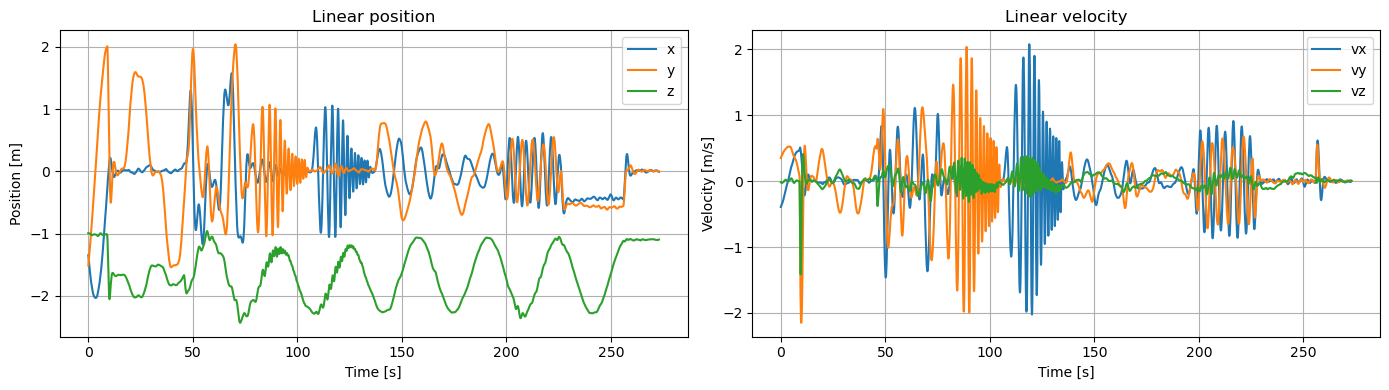

In [7]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load dataset
DATASET_PATH = os.path.join("dataset", "dataset_original.csv")
dataset_df   = pd.read_csv(DATASET_PATH)
dataset_np   = dataset_df.to_numpy(dtype=np.float32)

# dataset_original.csv is already preprocessed by the cell above.
# The control channels are the real logged PX4 inputs: thrust + body-rate commands.
# Reconstructed torques are intentionally not used.
dataset_np = from_quaternion_to_euler(dataset_np)

# ----- Global normalisation statistics for model inputs -----
mean, std = get_mean_and_std(dataset_np)
vel_mean     = mean[3:6];   vel_std     = std[3:6]
ang_vel_mean = mean[6:9];   ang_vel_std = std[6:9]
ctrl_mean    = mean[15:19]; ctrl_std    = std[15:19]

# ----- Train / val / test split -----
dt_candidates = dataset_np[:, 1]
dt_nominal    = float(np.median(dt_candidates[dt_candidates > 0])) if np.any(dt_candidates > 0) else 0.01
data_test_segments, data_train_val = split_data(
    dataset_np, time_period=1, dt=dt_nominal, t0=30, t1=150, t2=220)

# Shuffle and split train / val
pairs_curr, pairs_next = create_and_shuffle_pairs(data_train_val)
split_idx = int(0.8 * len(pairs_curr))
split_idx = min(max(split_idx, 1), len(pairs_curr) - 1)

train_data_current, val_data_current = pairs_curr[:split_idx], pairs_curr[split_idx:]
train_data_next,    val_data_next    = pairs_next[:split_idx], pairs_next[split_idx:]

# IMPORTANT:
# With real logged controls, use the CURRENT control row for x[k] -> x[k+1].
# The earlier "next" alignment mostly compensated the synthetic-torque leakage.
USE_NEXT_CONTROLS = False

X_train, X_train_next, U_train, dt_train = configure_training_and_validation_data(
    train_data_current, train_data_next, use_next_controls=USE_NEXT_CONTROLS)
X_val, X_val_next, U_val, dt_val = configure_training_and_validation_data(
    val_data_current, val_data_next, use_next_controls=USE_NEXT_CONTROLS)

# Keep 12-state slice used by physics / loss
X_train_phys      = X_train[:, :12].float()
X_train_next_phys = X_train_next[:, :12].float()
X_val_phys        = X_val[:, :12].float()
X_val_next_phys   = X_val_next[:, :12].float()
U_train = U_train.float(); dt_train = dt_train.float()
U_val   = U_val.float();   dt_val   = dt_val.float()

# ------------------------------------------------------------------
# Fit the hidden PX4 body-rate loop directly from the train split.
# Model per axis:
#    w_dot = a * w + b * u_rate + c
# This is much more faithful than treating logged rate commands as torques
# or as already-in-rad/s desired rates with a guessed time constant.
# ------------------------------------------------------------------
eps = 1e-8
dt_fit = dt_train.view(-1, 1).clamp_min(1e-4)
w_curr = X_train_phys[:, 9:12]
w_next = X_train_next_phys[:, 9:12]
u_rate = U_train[:, 1:4]
wdot_fd = (w_next - w_curr) / dt_fit

rate_w_coef = []
rate_u_coef = []
rate_bias = []
for j in range(3):
    Phi = torch.stack([
        w_curr[:, j],
        u_rate[:, j],
        torch.ones_like(w_curr[:, j]),
    ], dim=1)
    sol = torch.linalg.lstsq(Phi, wdot_fd[:, j]).solution
    rate_w_coef.append(sol[0].item())
    rate_u_coef.append(sol[1].item())
    rate_bias.append(sol[2].item())

RATE_W_COEF = torch.tensor(rate_w_coef, dtype=torch.float32)
RATE_U_COEF = torch.tensor(rate_u_coef, dtype=torch.float32)
RATE_BIAS   = torch.tensor(rate_bias, dtype=torch.float32)

print("Fitted body-rate surrogate coefficients:")
print("RATE_W_COEF =", RATE_W_COEF.tolist())
print("RATE_U_COEF =", RATE_U_COEF.tolist())
print("RATE_BIAS   =", RATE_BIAS.tolist())

# ------------------------------------------------------------------
# Residual normalisation for the NN output.
# The model predicts NORMALISED derivative corrections:
#     delta_vw_n = (delta_vw - r_mean) / r_std
# where delta_vw is in physical derivative units [m/s^2, rad/s^2].
# ------------------------------------------------------------------
with torch.no_grad():
    xdot_train = system_dynamics(X_train_phys, U_train, mass=mass, inertia=torch.tensor(inertia), g=g)
    X_phys_next_train = X_train_phys + xdot_train * dt_train.view(-1, 1)
    target_delta_vw_train = (X_train_next_phys[:, 6:12] - X_phys_next_train[:, 6:12]) / dt_train.view(-1, 1).clamp_min(1e-4)
    r_mean = target_delta_vw_train.mean(dim=0)
    r_std  = target_delta_vw_train.std(dim=0).clamp_min(1e-4)

print("Residual derivative stats:")
print("r_mean =", r_mean.tolist())
print("r_std  =", r_std.tolist())

# ----- Quick dataset overview -----
time = dataset_np[:, 0]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(time, dataset_np[:, 2], label="x")
ax[0].plot(time, dataset_np[:, 3], label="y")
ax[0].plot(time, dataset_np[:, 4], label="z")
ax[0].set_title("Linear position"); ax[0].set_xlabel("Time [s]")
ax[0].set_ylabel("Position [m]"); ax[0].legend(); ax[0].grid(True)
ax[1].plot(time, dataset_np[:, 5], label="vx")
ax[1].plot(time, dataset_np[:, 6], label="vy")
ax[1].plot(time, dataset_np[:, 7], label="vz")
ax[1].set_title("Linear velocity"); ax[1].set_xlabel("Time [s]")
ax[1].set_ylabel("Velocity [m/s]"); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()


**Step 5: Data Loss**

In [8]:
import torch
import torch.nn as nn

_mse_loss = nn.MSELoss()

def compute_new_pos_angles(delta_vw, xk, uk, dt, mass, inertia, g):
    """
    Integrate one step with derivative corrections delta_vw in PHYSICAL units:
      delta_vw[:,0:3] = v_dot correction [m/s^2]
      delta_vw[:,3:6] = w_dot correction [rad/s^2]
    """
    if dt.ndim == 1:
        dt = dt.view(-1, 1)

    x_dot_phys = system_dynamics(xk, uk, mass, inertia=inertia, g=g)

    delta_v = delta_vw[:, 0:3]
    delta_w = delta_vw[:, 3:6]

    v_next = xk[:, 6:9] + (x_dot_phys[:, 6:9] + delta_v) * dt
    w_next = xk[:, 9:12] + (x_dot_phys[:, 9:12] + delta_w) * dt

    v_curr = xk[:, 6:9]
    pos_next = xk[:, 0:3] + 0.5 * (v_curr + v_next) * dt

    roll0  = xk[:, 3]
    pitch0 = xk[:, 4]
    yaw0   = xk[:, 5]

    q0 = euler_to_quat(roll0, pitch0, yaw0)
    dq = omega_to_quat_delta(0.5 * (xk[:, 9:12] + w_next), dt)
    q_next = quat_mul(q0, dq)
    q_next = quat_normalize(q_next)
    rpy_next = wrap_to_pi(quat_to_euler(q_next))

    X_next = torch.zeros_like(xk)
    X_next[:, 0:3]  = pos_next
    X_next[:, 3:6]  = rpy_next
    X_next[:, 6:9]  = v_next
    X_next[:, 9:12] = w_next
    return X_next


def denormalize_delta_vw(delta_vw_n):
    rm = r_mean.to(device=delta_vw_n.device, dtype=delta_vw_n.dtype).view(1, 6)
    rs = r_std.to(device=delta_vw_n.device, dtype=delta_vw_n.dtype).view(1, 6)
    return delta_vw_n * rs + rm


def data_loss(model, xk, U_curr_NN, X_next, dt,
              mass=2.0, inertia=torch.tensor([0.0217, 0.0217, 0.04]), g=9.81,
              channel_weights=None, lambda_corr=0.0):
    """
    Train the NN on NORMALISED derivative residuals using RAW physical x and u.
    The model normalises its inputs internally, so do NOT pre-normalise here.
    """
    if dt.ndim == 1:
        dt = dt.view(-1, 1)

    zero_delta_vw = torch.zeros((xk.shape[0], 6), device=xk.device, dtype=xk.dtype)
    X_phys_next = compute_new_pos_angles(zero_delta_vw, xk, U_curr_NN, dt, mass, inertia, g)

    target_delta_vw = (X_next[:, 6:12] - X_phys_next[:, 6:12]) / dt.clamp_min(1e-4)
    rm = r_mean.to(device=xk.device, dtype=xk.dtype).view(1, 6)
    rs = r_std.to(device=xk.device, dtype=xk.dtype).view(1, 6)
    target_delta_vw_n = (target_delta_vw - rm) / rs

    delta_vw_n = model(xk, U_curr_NN)
    delta_vw = delta_vw_n * rs + rm

    error = delta_vw_n - target_delta_vw_n
    loss_data = torch.mean(error ** 2)
    per_channel_losses = torch.mean(error ** 2, dim=0)

    # regularise physical correction magnitude, not the normalised one
    loss_corr = torch.mean(delta_vw ** 2)

    total_loss = loss_data + lambda_corr * loss_corr
    return total_loss, {
        'loss_data': loss_data.detach(),
        'loss_corr': loss_corr.detach(),
        'per_channel': per_channel_losses.detach(),
    }


In [9]:
# Quick check: does uk or U_next give lower omega error with the fitted real-control model?

def sd_onestep(X_curr_phys, U_applied, dt, mass, inertia, g):
    if dt.ndim == 1:
        dt_ = dt.view(-1, 1)
    else:
        dt_ = dt
    xdot = system_dynamics(X_curr_phys, U_applied, mass, inertia, g)
    return X_curr_phys + xdot * dt_

U_val_curr = torch.tensor(np.array(val_data_current[:, 29:33], dtype=np.float32))
U_val_next = torch.tensor(np.array(val_data_next[:, 29:33], dtype=np.float32))

X_pred_using_Ucurr = sd_onestep(X_val_phys, U_val_curr, dt_val, mass, inertia, g)
X_pred_using_Unext = sd_onestep(X_val_phys, U_val_next, dt_val, mass, inertia, g)

err_curr = (X_pred_using_Ucurr[:, 9:12] - X_val_next_phys[:, 9:12]).abs().mean(dim=0)
err_next = (X_pred_using_Unext[:, 9:12] - X_val_next_phys[:, 9:12]).abs().mean(dim=0)

print("Mean |omega error| using U[k]:   ", err_curr.tolist())
print("Mean |omega error| using U[k+1]: ", err_next.tolist())


Mean |omega error| using U[k]:    [0.0066722664050757885, 0.006768934428691864, 0.0007044882513582706]
Mean |omega error| using U[k+1]:  [0.007838518358767033, 0.009639124386012554, 0.0007189742755144835]


**Step 6: Training and Validation**

Training uses **one-step supervised learning on (current, next) state pairs only** — no windows, no horizons, and no multi-step rollout.

**Why pairs only?**  
Each training example is a single transition `(x_k, u_k) → x_{k+1}`: the model predicts the one-step residual correction and is penalised on the MSE between the predicted and true next state. This is the minimal, cleanest form of supervised physics-correcting learning.

**Preventing interlinking across trajectories:**  
The dataset is assembled by stacking multiple flight segments.  At each segment boundary the first row of the new segment has `dt = 0` (set by `dataset_masking`).  `create_and_shuffle_pairs` filters these rows out as "next" states before any shuffling, so no pair ever links the end of one trajectory to the start of another.

**Training loop:**
* Mini-batches of size `BATCH_SIZE` are drawn from the shuffled pair dataset.
* For each batch: forward pass → `data_loss` (MSE + L2 correction penalty) → `loss.backward()` → gradient clip → `optimizer.step()`.
* Validation uses the full held-out pair set (full-batch, no gradient).
* Early stopping monitors val loss; best checkpoint is restored at the end.


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Hyper-parameters ──────────────────────────────────────────────────────────────
HIDDEN_LAYERS  = [16, 32, 16]   # smaller model → better generalisation try 32, 32, 32
DROPOUT_RATE   = 0.1            # dropout between hidden layers
LEARNING_RATE  = 1e-3
WEIGHT_DECAY   = 1e-4           # L2 weight regularisation (Adam)
BATCH_SIZE     = 512            # mini-batch size
GRAD_CLIP      = 1.0            # max gradient norm
NUM_EPOCHS     = 50000
LAMBDA_CORR    = 1           # L2 penalty on NN correction magnitude
EARLY_STOP_PAT = 3000           # patience epochs for early stopping
MIN_DELTA      = 1e-7           # minimum val-loss improvement to reset patience


In [17]:
# Normalization
norm = DynamicsNormalizer(
    pos_scale=10.0,
    angle_scale=np.pi,
    vel_scale=5.0,
    omega_scale=5.0,
    u_scale=1.0
).to(device)
# ── Model ────────────────────────────────────────────────────────────────────────
model = ResidualBModel(
    hidden_layers_size=HIDDEN_LAYERS,
    activation_fn=nn.ELU,
    output_activation=nn.Identity,
    dropout_rate=DROPOUT_RATE,
    vel_mean=vel_mean,         vel_std=vel_std,
    ang_vel_mean=ang_vel_mean, ang_vel_std=ang_vel_std,
    ctrl_mean=ctrl_mean,       ctrl_std=ctrl_std,
).to(device)

# ── Optimizer ──────────────────────────────────────────────────────────────────
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# ── LR schedulers ─────────────────────────────────────────────────────────────
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=3500, eta_min=1e-4)
scheduler_plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=300,
    threshold=1e-5, threshold_mode='abs', min_lr=1e-5)

# ── Move pair tensors to device ──────────────────────────────────────────────────────
# These tensors were built in Cell 9 from boundary-clean shuffled pairs.
X_train_phys_d      = X_train_phys.to(device)
X_train_next_phys_d = X_train_next_phys.to(device)
U_train_d           = U_train.to(device)
dt_train_d          = dt_train.to(device)

X_val_phys_d      = X_val_phys.to(device)
X_val_next_phys_d = X_val_next_phys.to(device)
U_val_d           = U_val.to(device)
dt_val_d          = dt_val.to(device)

# # ── Channel weights ──────────────────────────────────────────────────────────────
# channel_weights = torch.tensor(
#     [0.1, 0.1, 0.1,   # x, y, z
#      0.1, 0.1, 0.1,   # roll, pitch, yaw
#      1.0, 1.0, 1.0,   # vx, vy, vz
#      1.0, 1.0, 1.0],  # w_roll, w_pitch, w_yaw
#     device=device, dtype=X_train_phys_d.dtype)

# ── Pair DataLoader ─────────────────────────────────────────────────────────────
# Training uses only (current, next) pairs.  No windows or multi-step
# horizons are used.  Cross-trajectory boundary pairs were already removed
# by create_and_shuffle_pairs in Cell 9, so each pair is guaranteed to
# belong to a single continuous flight segment.
train_dataset = TensorDataset(X_train_phys_d, U_train_d,
                               X_train_next_phys_d, dt_train_d)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"Train pairs: {len(train_dataset)}  |  Val pairs: {X_val_phys_d.shape[0]}")

# ── Training state ──────────────────────────────────────────────────────────────
train_losses   = []
val_losses     = []
lr_history     = []
per_ch_train   = [[] for _ in range(6)]
per_ch_val     = [[] for _ in range(6)]

best_val_loss    = float('inf')
best_model_state = None
patience_counter = 0

mass_    = 2.0
inertia_ = torch.tensor([0.0217, 0.0217, 0.04])
g_       = 9.81

# ── Training loop (pair-based) ───────────────────────────────────────────────────


NameError: name 'DynamicsNormalizer' is not defined

In [10]:
#NN_architecture:
  n_input : 16  # angular positions (represented with sin,cos components) (6), linear and angular velocities (6) + control inputs (4)
  n_output : 12  # linear and angular velocities rates, linear positions rates, angular positions rates (12)
  hidden_layers_size : [256, 256, 64] 
  activation_fns : [SiLU, SiLU, Tanh] # GELU, SiLU, ReLU, LeakyReLU, Tanh, etc. (one per hidden layer) --- if not provided, it will default to ReLU for all layers
  #activation_fn : Tanh # fallback if activation_fns is not provided
  
  normalization: "none" # none | layernorm | batchnorm
  norm_eps: 1.0e-5
  dropout: 0 #0.05 (actually the dropout was making my training worse)In the 

IndentationError: unexpected indent (556987233.py, line 2)

In [14]:
class NN(nn.Module):
    def __init__(
        self,
        n_input,
        n_output,
        hidden_layers_size,
        activation_fns=(nn.Softplus,),
        normalization="none",
        norm_eps=1e-5,
        dropout=0.0,
    ):
        super().__init__()
        self.n_input = n_input
        self.n_output = n_output
        self.hidden_layers_size = hidden_layers_size
        self.activation_fns = activation_fns
        self.normalization = normalization
        self.norm_eps = norm_eps
        self.dropout = dropout

        # Allow a single activation to be reused across all hidden layers.
        if len(self.activation_fns) == 1 and len(hidden_layers_size) > 1:
            self.activation_fns = tuple(self.activation_fns) * len(hidden_layers_size)
        if len(self.activation_fns) != len(hidden_layers_size):
            raise ValueError(
                "activation_fns must have length 1 or match hidden_layers_size"
            )

        # Build network
        layers = []
        in_features = n_input
        for i, out_features in enumerate(hidden_layers_size):
            layers.append(nn.Linear(in_features, out_features))

            if normalization == "layernorm":
                layers.append(nn.LayerNorm(out_features, eps=norm_eps))
            elif normalization == "batchnorm":
                layers.append(nn.BatchNorm1d(out_features, eps=norm_eps))
            elif normalization == "none":
                pass
            else:
                raise ValueError(f"Unsupported normalization: {normalization}")

            layers.append(self.activation_fns[i]())
            if dropout and dropout > 0: # the dropout is used to prevent overfitting by randomly setting a fraction of the input units to 0 at each update during training time, which helps to prevent the model from relying too heavily on any particular set of features and encourages it to learn more robust representations. The value of dropout is a hyperparameter that can be tuned based on the specific problem and dataset, with common values being in the range of 0.1 to 0.5.
                layers.append(nn.Dropout(p=dropout))

            in_features = out_features

        layers.append(nn.Linear(hidden_layers_size[-1], n_output))

        self.network = nn.Sequential(*layers)

        # Initialize weights
        for m in self.modules():
            if isinstance(m, nn.Linear):
                # Match init to activation to keep variance stable.
                if any(
                    act.__name__.lower() in {"ReLU", "LeakyReLU", "SiLU", "GELU"}
                    for act in self.activation_fns
                ):
                    nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
                else:
                    nn.init.xavier_uniform_(m.weight)
                #nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, Z): #Z is the input tensor that contains both the current state and the control input, concatenated together. The forward method processes this input through the network to produce a prediction of the next state. The output of the network is interpreted as a delta (change) from the current state, which is then added to the current state to get the next state prediction.
        """
        Z: Input tensor [batch_size, n_input] = [state, control]
        returns: next_state_prediction [batch_size, n_output]
        """
        #current_state = Z[:,:self.n_output] # Extract current state from input tensor (first n_output elements of Z calculated in the previous time step)
        delta = self.network(Z) # Neural network output
        #next_state_prediction = current_state + delta
        prediction = delta # The NN directly predicts the next state, without adding the current state (so it is not a delta prediction but a direct prediction of the next state)
        return prediction

def model_definition(
    NN,
    n_input,
    n_output,
    hidden_layers_size,
    activation_fns,
    normalization="none",
    norm_eps=1e-5,
    dropout=0.0,
):
    model = NN(
        n_input=n_input,
        n_output=n_output,
        hidden_layers_size=hidden_layers_size,
        activation_fns=activation_fns,
        normalization=normalization,
        norm_eps=norm_eps,
        dropout=dropout,
    )
    return model


In [11]:
trained_model = "best_model_20260505-173426_dp.pth"

In [13]:
import torch
import torch.nn as nn

# 1. Map the string names from your config directly to PyTorch objects
ACTIVATIONS = (nn.SiLU, nn.SiLU, nn.Tanh)

# 2. Instantiate the model using the exact specs from your YAML config file
model = model_definition(
    NN=NN,
    n_input=16,
    n_output=12,
    hidden_layers_size=[128, 64, 32],
    activation_fns=ACTIVATIONS,
    normalization="none",
    norm_eps=1e-5,
    dropout=0.0
)

# 3. Load your specific saved weights safely onto your current device
model.load_state_dict(torch.load("best_model_20260505-173426_dp.pth", map_location=device))

# 4. Set to evaluation mode and assign to device
model = model.to(device)
model.eval()

NameError: name 'device' is not defined

In [19]:
import torch
import torch.nn as nn

class NN(nn.Module):
    def __init__(
        self,
        n_input,
        n_output,
        hidden_layers_size,
        activation_fns=(nn.Softplus,),
        normalization="none",
        norm_eps=1e-5,
        dropout=0.0,
    ):
        super().__init__()
        self.n_input = n_input
        self.n_output = n_output
        self.hidden_layers_size = hidden_layers_size
        self.activation_fns = activation_fns
        self.normalization = normalization
        self.norm_eps = norm_eps
        self.dropout = dropout

        # Allow a single activation to be reused across all hidden layers.
        if len(self.activation_fns) == 1 and len(hidden_layers_size) > 1:
            self.activation_fns = tuple(self.activation_fns) * len(hidden_layers_size)
        if len(self.activation_fns) != len(hidden_layers_size):
            raise ValueError(
                "activation_fns must have length 1 or match hidden_layers_size"
            )

        # Build network
        layers = []
        in_features = n_input
        for i, out_features in enumerate(hidden_layers_size):
            layers.append(nn.Linear(in_features, out_features))

            if normalization == "layernorm":
                layers.append(nn.LayerNorm(out_features, eps=norm_eps))
            elif normalization == "batchnorm":
                layers.append(nn.BatchNorm1d(out_features, eps=norm_eps))
            elif normalization == "none":
                pass
            else:
                raise ValueError(f"Unsupported normalization: {normalization}")

            layers.append(self.activation_fns[i]())
            if dropout and dropout > 0:
                layers.append(nn.Dropout(p=dropout))

            in_features = out_features

        layers.append(nn.Linear(hidden_layers_size[-1], n_output))
        self.network = nn.Sequential(*layers)

        # Initialize weights
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if any(
                    act.__name__.lower() in {"relu", "leakyrelu", "silu", "gelu"}
                    for act in self.activation_fns
                ):
                    nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
                else:
                    nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, Z):
        delta = self.network(Z) 
        prediction = delta 
        return prediction

def model_definition(
    NN,
    n_input,
    n_output,
    hidden_layers_size,
    activation_fns,
    normalization="none",
    norm_eps=1e-5,
    dropout=0.0,
):
    model = NN(
        n_input=n_input,
        n_output=n_output,
        hidden_layers_size=hidden_layers_size,
        activation_fns=activation_fns,
        normalization=normalization,
        norm_eps=norm_eps,
        dropout=dropout,
    )
    return model

# --- Instantiation and Loading ---
trained_model_path = "best_model_20260505-173426_dp.pth"

# 1. Map the string names from your config directly to PyTorch objects
ACTIVATIONS = (nn.SiLU, nn.SiLU, nn.Tanh)

# 2. Instantiate the model using the exact specs from your YAML config file
trained_model = model_definition(
    NN=NN,
    n_input=16,
    n_output=12,
    hidden_layers_size=[128, 64, 32],
    activation_fns=ACTIVATIONS,
    normalization="none",
    norm_eps=1e-5,
    dropout=0.0
)

state_dict = torch.load(trained_model_path, map_location=device)
clean_state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}
trained_model.load_state_dict(clean_state_dict)
trained_model = trained_model.to(device)
trained_model.eval()

NN(
  (network): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): SiLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=12, bias=True)
  )
)

**Step 8: Plot position error in 3D**

In [20]:
@torch.no_grad()
def _f_phys_nn(model, x, u, dt, mass, inertia, g, use_nn: bool):
    if dt.ndim == 1:
        dt = dt.view(-1, 1)
    elif dt.ndim == 0:
        dt = dt.view(1, 1)

    xdot = system_dynamics(x, u, mass, inertia, g)

    if not use_nn:
        return xdot

    delta_vw_n = model(x, u)
    delta_vw = denormalize_delta_vw(delta_vw_n)

    xdot_corr = torch.zeros_like(xdot)
    xdot_corr[:, 6:9]  = delta_vw[:, 0:3]
    xdot_corr[:, 9:12] = delta_vw[:, 3:6]

    return xdot + xdot_corr


@torch.no_grad()
def _rk4_step(model, x, u, dt, mass, inertia, g, use_nn: bool):
    if dt.ndim == 1:
        dt = dt.view(-1, 1)
    elif dt.ndim == 0:
        dt = dt.view(1, 1)

    k1 = _f_phys_nn(model, x,             u, dt, mass, inertia, g, use_nn)
    k2 = _f_phys_nn(model, x + 0.5*dt*k1, u, dt, mass, inertia, g, use_nn)
    k3 = _f_phys_nn(model, x + 0.5*dt*k2, u, dt, mass, inertia, g, use_nn)
    k4 = _f_phys_nn(model, x + 1.0*dt*k3, u, dt, mass, inertia, g, use_nn)

    return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


@torch.no_grad()
def _euler_step(model, x, u, dt, mass, inertia, g, use_nn: bool):
    if dt.ndim == 1:
        dt = dt.view(-1, 1)
    elif dt.ndim == 0:
        dt = dt.view(1, 1)

    if use_nn:
        delta_vw = denormalize_delta_vw(model(x, u))
    else:
        delta_vw = torch.zeros((x.shape[0], 6), device=x.device, dtype=x.dtype)

    return compute_new_pos_angles(delta_vw, x, u, dt, mass, inertia, g)


def multistep_rollout(model, X0, U_seq, dt_seq, mass, inertia, g,
                      use_nn=True, integrator='euler'):
    if dt_seq.ndim != 1:
        dt_seq = dt_seq.view(-1)

    dev = X0.device
    dtype = X0.dtype
    N_steps = U_seq.shape[0]

    X_hat = torch.zeros((N_steps + 1, 12), device=dev, dtype=dtype)
    X_hat[0] = X0

    x = X0.view(1, 12)
    integrator = integrator.lower()
    if integrator not in ('euler', 'rk4'):
        raise ValueError(f"integrator must be 'euler' or 'rk4', got {integrator}")

    for k in range(N_steps):
        u = U_seq[k].view(1, 4)
        dt = dt_seq[k].view(1, 1)

        if integrator == 'euler':
            x_next = _euler_step(model, x, u, dt, mass, inertia, g, use_nn)
        else:
            x_next = _rk4_step(model, x, u, dt, mass, inertia, g, use_nn)

        X_hat[k + 1] = x_next.view(12)
        x = x_next

    return X_hat

In [21]:
import numpy as np
import torch

def _build_Z_like_test_model(x, u, mean, std, device, dtype):
    """
    x: torch (1,12) state in standard order:
       [x,y,z, roll,pitch,yaw, vx,vy,vz, w_roll,w_pitch,w_yaw]
    u: torch (1,4)
    Returns Z: torch (1,16) same layout as in your test_model code.
    """
    # normalize_NN_inputs is numpy-based in your snippet
    x_np = x.detach().cpu().numpy().reshape(-1)  # (12,)
    u_np = u.detach().cpu().numpy().reshape(-1)  # (4,)
    x_n, u_n = normalize_NN_inputs(x_np, u_np, mean, std)

    roll, pitch, yaw = float(x_n[3]), float(x_n[4]), float(x_n[5])
    sinr, cosr = np.sin(roll), np.cos(roll)
    sinp, cosp = np.sin(pitch), np.cos(pitch)
    siny, cosy = np.sin(yaw), np.cos(yaw)

    vx_n, vy_n, vz_n = float(x_n[6]), float(x_n[7]), float(x_n[8])
    wx_n, wy_n, wz_n = float(x_n[9]), float(x_n[10]), float(x_n[11])

    thrust_n, tr_n, tp_n, ty_n = map(float, u_n)

    Z = torch.tensor([[sinr, cosr,
                       sinp, cosp,
                       siny, cosy,
                       vx_n, vy_n, vz_n,
                       wx_n, wy_n, wz_n,
                       thrust_n, tr_n, tp_n, ty_n]],
                     device=device, dtype=dtype)
    return Z


def _nn_out_to_xdot_standard(nn_out, x):
    """
    nn_out in your test_model ordering:
      [vx_dot, vy_dot, vz_dot, w_roll_dot, w_pitch_dot, w_yaw_dot,
       x_dot,  y_dot,  z_dot,  roll_dot, pitch_dot, yaw_dot]

    Convert to standard derivative order compatible with your state vector:
      [x_dot, y_dot, z_dot, roll_dot, pitch_dot, yaw_dot,
       vx_dot, vy_dot, vz_dot, w_roll_dot, w_pitch_dot, w_yaw_dot]
    """
    if nn_out.ndim == 1:
        nn_out = nn_out.view(1, 12)

    vx_dot, vy_dot, vz_dot = nn_out[:, 0], nn_out[:, 1], nn_out[:, 2]
    wr_dot, wp_dot, wy_dot = nn_out[:, 3], nn_out[:, 4], nn_out[:, 5]
    x_dot,  y_dot,  z_dot  = nn_out[:, 6], nn_out[:, 7], nn_out[:, 8]
    r_dot,  p_dot,  ya_dot = nn_out[:, 9], nn_out[:, 10], nn_out[:, 11]

    xdot = torch.stack([x_dot, y_dot, z_dot,
                        r_dot, p_dot, ya_dot,
                        vx_dot, vy_dot, vz_dot,
                        wr_dot, wp_dot, wy_dot], dim=1)
    return xdot.to(device=x.device, dtype=x.dtype)


def _fullnn_xdot(model, x, u, mean, std):
    """
    model: your already-trained full-state model
    x: (1,12) torch
    u: (1,4)  torch
    returns x_dot (1,12) torch in STANDARD order
    """
    device = x.device
    dtype = x.dtype

    Z = _build_Z_like_test_model(x, u, mean, std, device=next(model.parameters()).device,
                                 dtype=next(model.parameters()).dtype)
    with torch.no_grad():
        nn_out = model(Z)  # (1,12) in test_model ordering

    # move output to x device/dtype and reorder
    nn_out = nn_out.to(device=device, dtype=dtype)
    return _nn_out_to_xdot_standard(nn_out, x)


def _rk4_step_fullnn(model, x, u, dt, mean, std):
    k1 = _fullnn_xdot(model, x, u, mean, std)
    k2 = _fullnn_xdot(model, x + 0.5 * dt * k1, u, mean, std)
    k3 = _fullnn_xdot(model, x + 0.5 * dt * k2, u, mean, std)
    k4 = _fullnn_xdot(model, x + dt * k3, u, mean, std)
    return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


def _euler_step_fullnn(model, x, u, dt, mean, std):
    return x + dt * _fullnn_xdot(model, x, u, mean, std)


def multistep_rollout_fullnn(model, X0, U_seq, dt_seq, *, mean, std, integrator="rk4"):
    """
    Rollout using ONLY your trained full-state NN.
    Returns (N+1,12) X_hat so you can plot exactly like your residual viz code.
    """
    if dt_seq.ndim != 1:
        dt_seq = dt_seq.view(-1)

    dev = X0.device
    dtype = X0.dtype
    N_steps = U_seq.shape[0]

    X_hat = torch.zeros((N_steps + 1, 12), device=dev, dtype=dtype)
    X_hat[0] = X0

    x = X0.view(1, 12)
    integrator = integrator.lower()
    if integrator not in ("euler", "rk4"):
        raise ValueError(f"integrator must be 'euler' or 'rk4', got {integrator}")

    for k in range(N_steps):
        u = U_seq[k].view(1, 4)
        dt = dt_seq[k].view(1, 1)

        if integrator == "euler":
            x = _euler_step_fullnn(model, x, u, dt, mean, std)
        else:
            x = _rk4_step_fullnn(model, x, u, dt, mean, std)

        X_hat[k + 1] = x.view(12)

    return X_hat

def build_aligned_transitions(X, U, dt, delay_mode="curr"):
    """
    X : (N,12)
    U : (N,4)
    dt: (N,) or (N,1)

    Returns:
      xk      : (N-1,12)
      X_next  : (N-1,12)
      uk      : (N-1,4)
      dt_curr : (N-1,1)

    delay_mode='next': use U[k+1], dt[k+1] for transition x[k] -> x[k+1]
    delay_mode='curr': use U[k],   dt[k+1] for transition x[k] -> x[k+1]
    """
    if dt.ndim == 1:
        dt = dt.view(-1, 1)

    xk = X[:-1]
    X_next = X[1:]
    dt_curr = dt[1:]

    if delay_mode == "next":
        uk = U[1:]
    elif delay_mode == "curr":
        uk = U[:-1]
    else:
        raise ValueError(f"delay_mode must be 'next' or 'curr', got {delay_mode}")

    return xk, X_next, uk, dt_curr

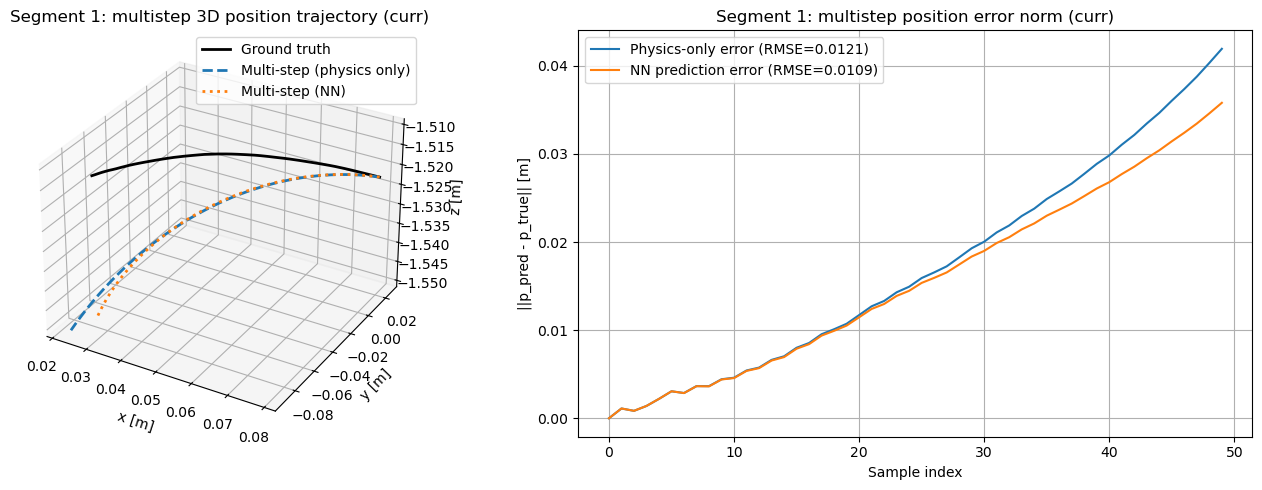

Segment 1 position RMSE -> physics-only: 0.012091, physics+NN: 0.010890


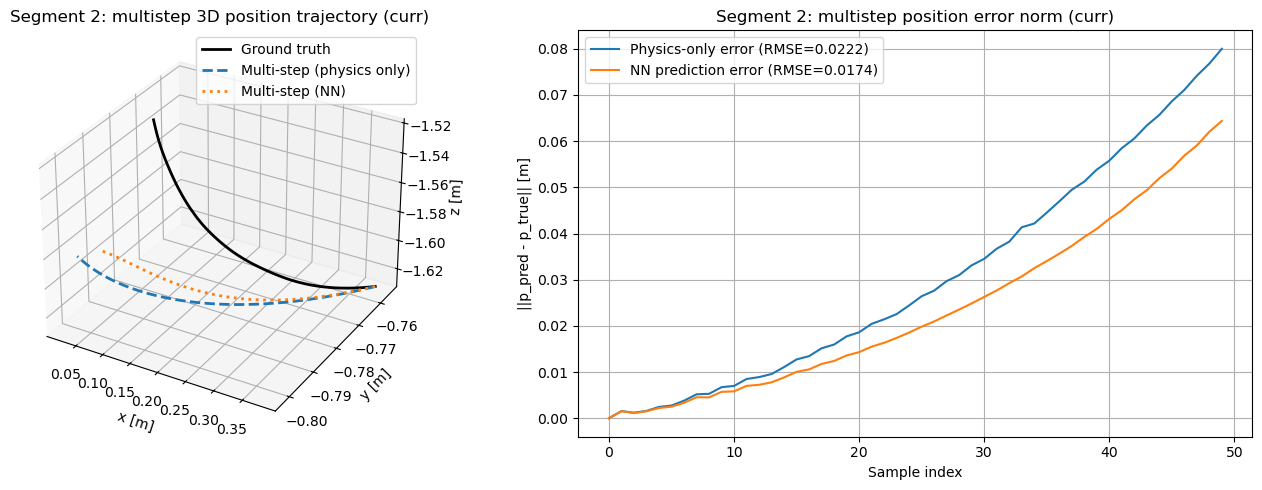

Segment 2 position RMSE -> physics-only: 0.022233, physics+NN: 0.017358


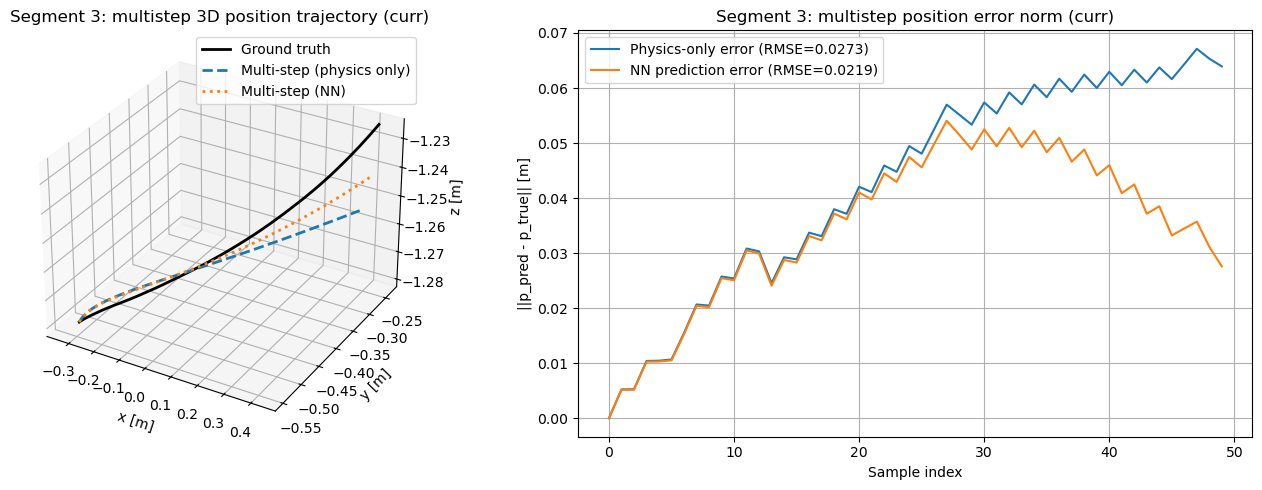

Segment 3 position RMSE -> physics-only: 0.027259, physics+NN: 0.021874


In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt

model = trained_model.to(device)
model.eval()

delay_mode = "curr"

for seg_idx, seg in enumerate(data_test_segments, start=1):
    if seg.shape[0] < 3:
        continue

    states, controls, dt_seg = configure_data(seg)

    X = torch.tensor(states[:, :12], dtype=torch.float32, device=device)
    U = torch.tensor(controls, dtype=torch.float32, device=device)
    dt = torch.tensor(dt_seg.squeeze(-1), dtype=torch.float32, device=device)

    _, X_next_gt, U_seq, dt_seq = build_aligned_transitions(X, U, dt, delay_mode=delay_mode)

    with torch.no_grad():
        X_hat_phys = multistep_rollout(
            model=model,
            X0=X[0],
            U_seq=U_seq,
            dt_seq=dt_seq.view(-1),
            mass=mass,
            inertia=inertia,
            g=g,
            use_nn=False,
            integrator="rk4"
        )

        X_hat_nn = multistep_rollout_fullnn(
            model=model,
            X0=X[0],
            U_seq=U_seq,
            dt_seq=dt_seq.view(-1),
            mean=mean,
            std=std,
            integrator="rk4",
        )

    gt_pos = X[:, 0:3].detach().cpu().numpy()
    phys_pos = X_hat_phys[:, 0:3].detach().cpu().numpy()
    nn_pos   = X_hat_nn[:, 0:3].detach().cpu().numpy()

    err_phys = np.linalg.norm(phys_pos - gt_pos, axis=1)
    err_nn   = np.linalg.norm(nn_pos   - gt_pos, axis=1)

    rmse_phys = float(np.sqrt(np.mean((phys_pos - gt_pos) ** 2)))
    rmse_nn   = float(np.sqrt(np.mean((nn_pos   - gt_pos) ** 2)))

    fig = plt.figure(figsize=(14, 5))

    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot(gt_pos[:, 0], gt_pos[:, 1], gt_pos[:, 2], label="Ground truth", linewidth=2, color = "black")
    ax1.plot(phys_pos[:, 0], phys_pos[:, 1], phys_pos[:, 2], "--", label="Multi-step (physics only)", linewidth=2)
    ax1.plot(nn_pos[:, 0], nn_pos[:, 1], nn_pos[:, 2], ":", label="Multi-step (NN)", linewidth=2)
    ax1.set_title(f"Segment {seg_idx}: multistep 3D position trajectory ({delay_mode})")
    ax1.set_xlabel("x [m]")
    ax1.set_ylabel("y [m]")
    ax1.set_zlabel("z [m]")
    ax1.legend()

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.plot(err_phys, label=f"Physics-only error (RMSE={rmse_phys:.4f})")
    ax2.plot(err_nn,   label=f"NN prediction error (RMSE={rmse_nn:.4f})")
    ax2.set_title(f"Segment {seg_idx}: multistep position error norm ({delay_mode})")
    ax2.set_xlabel("Sample index")
    ax2.set_ylabel("||p_pred - p_true|| [m]")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print(f"Segment {seg_idx} position RMSE -> physics-only: {rmse_phys:.6f}, physics+NN: {rmse_nn:.6f}")

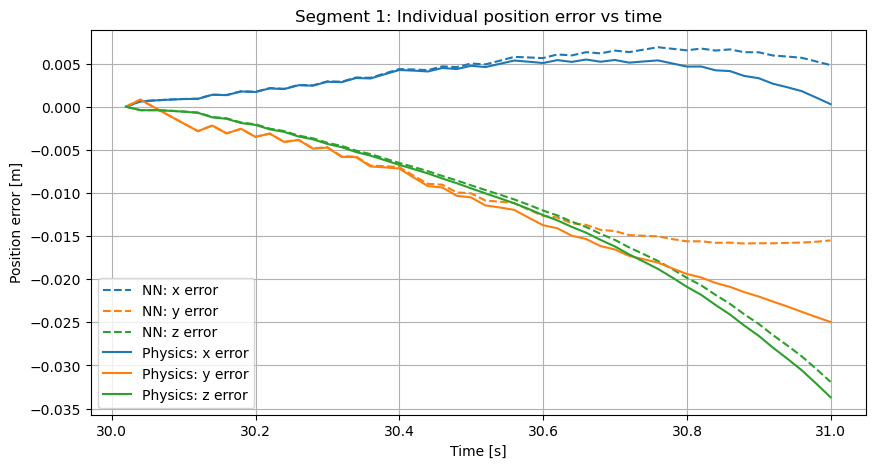

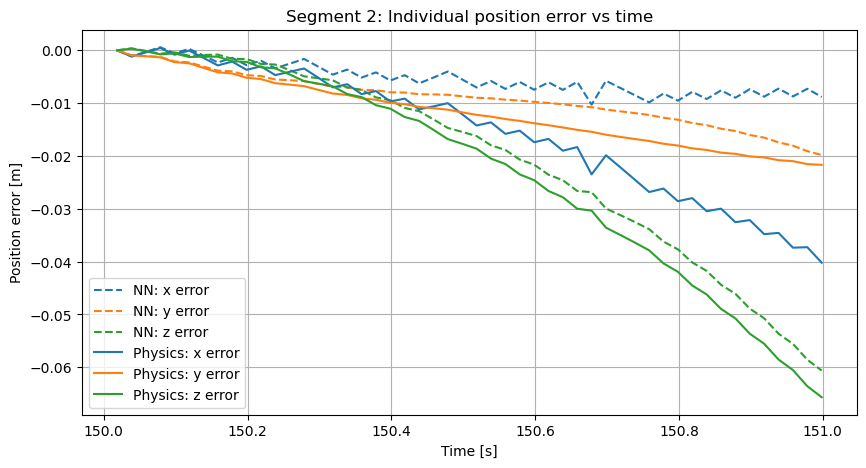

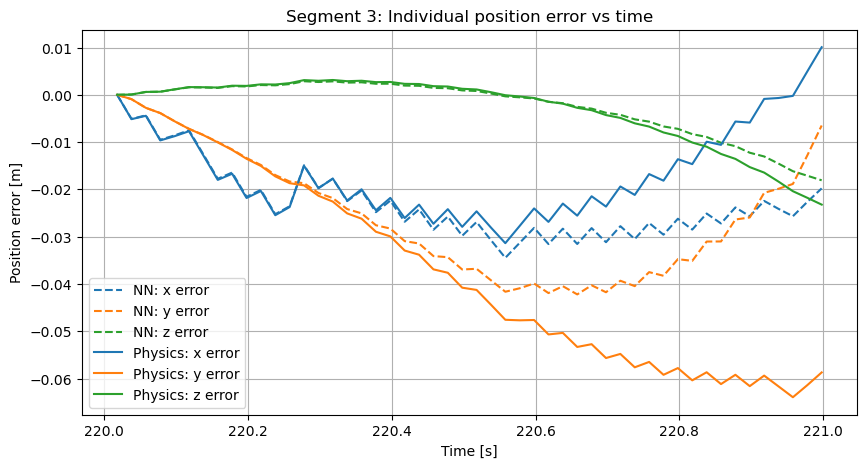

In [23]:
for seg_i, seg in enumerate(data_test_segments):

    states_np, controls_np, dt_np = configure_data(seg)

    X = torch.tensor(states_np[:, :12], dtype=torch.float32, device=device)
    U = torch.tensor(controls_np, dtype=torch.float32, device=device)

    # Time vector
    t = seg[:, 0].astype(np.float32)

    # Per-step dt
    dt_seq = torch.tensor(t[1:] - t[:-1], dtype=torch.float32, device=device)

    # Inputs aligned with transitions
    U_seq = U[:-1, :]

    # Initial state
    X0 = X[0]

    # Rollouts
    X_hat_phys = multistep_rollout(
        model=model,
        X0=X[0],
        U_seq=U_seq,
        dt_seq=dt_seq.view(-1),
        mass=mass,
        inertia=inertia,
        g=g,
        use_nn=False,
        integrator="rk4"
    )
    X_hat_nn = multistep_rollout_fullnn(
        model=model,
        X0=X[0],
        U_seq=U_seq,
        dt_seq=dt_seq.view(-1),
        mean=mean,
        std=std,
        integrator="rk4",
    )

    # Convert to numpy
    gt_pos   = X[:, 0:3].detach().cpu().numpy()           # (N,3)
    phys_pos = X_hat_phys[:, 0:3].detach().cpu().numpy()  # (N,3)
    nn_pos   = X_hat_nn[:, 0:3].detach().cpu().numpy()    # (N,3)
    
    # Individual axis error (vector), shape (N,3)
    err_phys_xyz = phys_pos - gt_pos
    err_nn_xyz   = nn_pos   - gt_pos
    
    # Optional: error magnitude (1D), shape (N,)
    err_phys_norm = np.linalg.norm(err_phys_xyz, axis=1)
    err_nn_norm   = np.linalg.norm(err_nn_xyz, axis=1)
    

    plt.figure(figsize=(10,5))
    plt.plot(t, err_nn_xyz[:, 0], "C0--", label="NN: x error")
    plt.plot(t, err_nn_xyz[:, 1], "C1--", label="NN: y error")
    plt.plot(t, err_nn_xyz[:, 2], "C2--", label="NN: z error")
    
    plt.plot(t, err_phys_xyz[:, 0], "C0-", label="Physics: x error")
    plt.plot(t, err_phys_xyz[:, 1], "C1-", label="Physics: y error")
    plt.plot(t, err_phys_xyz[:, 2], "C2-", label="Physics: z error")
    
    plt.xlabel("Time [s]")
    plt.ylabel("Position error [m]")
    plt.title(f"Segment {seg_i+1}: Individual position error vs time")
    plt.legend()
    plt.grid(True)
    plt.show()